# Markov Chain Monte Carlo

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import preliz as pz
from tqdm.auto import tqdm
plt.rcParams["figure.figsize"] = (15,3)
plt.style.use('ggplot')

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


## Exercise 1: Single-chain Metropolis algorithm from scratch

The Metropolis algorithm is a very good start into the world of Markov Chain Monte Carlo. Even though it is less effective than Hamiltonian MCMC or NUTS, its simplicity allows easy investigation of the principles of MCMC algorithms. In this exercise you will build the Metropolis algorithm from scratch and apply it to a problem with binomial likelihood. We'll still use the Beta prior from last week, but pretend we don't know the analytical solution yet (of course we'll use it to verify whether our implementation works correctly so that later we can work with arbitrary priors).

**Problem to solve:**
Given $\alpha=5$, $\beta=2$, $n=10$ and $k=8$
* $\pi \sim Beta(\alpha, \beta)$ (prior)
* $Y=k|\pi \sim Bin(n,\pi)$ (likelihood)
* $\pi|Y=k \sim ?$ (posterior)

Problem definition:

In [2]:
alpha = 5
beta = 2
n = 10
k = 8

**a) Proposal distribution**

You will use a Gaussian jump proposal distribution for this particular implementation. Implement a Python function `propose_jump(pi, sigma)`, where `pi` is the current value in the chain and `sigma` is the standard deviation of the proposal distribution. Use `scipy.stats.norm.rvs()` to propose a new value $\pi^{\prime}\sim N(\pi,\sigma^{2})$ that is returned by the function.

In [3]:
def propose_jump( pi, sigma ):
    return stats.norm.rvs( loc=pi, scale=sigma )

propose_jump( 0.3, 0.1 )

0.3145445223454777

**b) Random walk**

Create a simple (Markovian) Monte Carlo chain using your `propose_jump()` function. Initialize your chain with a random value for $\pi$ from the interval $[0, 1]$ and accept all proposed jumps. Do this for 1000 iterations with a standard deviation of `sigma = 0.2`. Plot the values of the resulting chain (random walk). Run your code multiple times and look at the different random walks you produced.
**Hint:** Make sure you clip the proposed values to a range between 0 and 1. The proposal distribution is not aware of the fact that $\pi$ is bounded between 0 and 1.

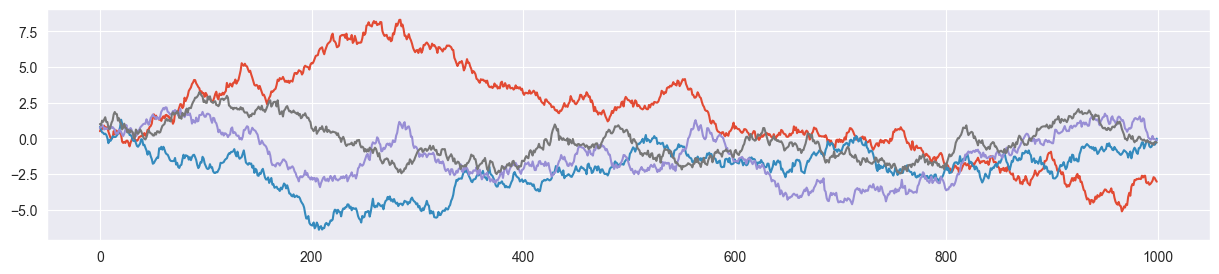

In [4]:
def plot_random_walk( sigma=0.2 ):
    pi = np.random.rand()
    chain = []
    for i in range(1000):
        pi = propose_jump( pi, sigma=sigma )
        chain.append( pi )
    plt.plot( chain )

plot_random_walk( sigma=0.2 )
plot_random_walk( sigma=0.2 )
plot_random_walk( sigma=0.2 )
plot_random_walk( sigma=0.2 )

**c) Jump decision**

In the Metropolis algorithm (assuming a symmetric proposal function), the classic random walk is nudged towards our posterior by applying a decision rule for whether a proposed jump is accepted. This rule is the following:

Given are the current value $\pi$ in the chain and the proposed value $\pi^{\prime}$. Jump to $\pi^{\prime}$ with the probability
$$\alpha=min\left\{1,\frac{p(\pi^{\prime})P(Y=k|\pi^{\prime})}{p(\pi)P(Y=k|\pi)}\right\}$$

Once you have computed $\alpha$ (**Hint:** use `stats.beta.pdf()` and `stats.binom.pmf()`), you may sample a value $p\sim U(0,1)$ (using `np.random.rand()`) and use the following decision rule:
* If $p\le\alpha$ return the proposed value $\pi^{\prime}$ (accept)
* If $p>\alpha$ return the original value $\pi$ (reject)

Write a function `decide(pi, pi2, alpha, beta, n, k)`, where `pi` is the current value in the chain, `pi2` is the proposed value by `propose_jump(pi, sigma)`, `alpha` and `beta` define the beta prior and `n` and `k` describe the measured binomially distributed data. Test your function by defining a fixed value for `pi`, proposing a jump `pi2` with your `propose_jump()` function, run it through `decide()` and verify that it sometimes returns `pi` and sometimes the proposed value.

**Hints:**
* You may print out or return $\alpha$ to verify whether your code works correctly.
* The jump proposal function might propose a value of $\pi$ outside of its domain $[0, 1]$. Make sure that in that case the proposal is rejected.

In [5]:
def decide( pi, pi2, alpha, beta, n, k, debug=False ):
    # evaluate prior and likelihood
    prior1 = stats.beta.pdf( pi, alpha, beta )
    prior2 = stats.beta.pdf( pi2, alpha, beta )
    likelihood1 = stats.binom.pmf( n=n, k=k, p=pi )
    likelihood2 = stats.binom.pmf( n=n, k=k, p=pi2 )

    # define alpha
    alpha = min( 1, prior2/prior1 * likelihood2/likelihood1 )
    if debug: print("pi = {:.5f}, pi2 = {:.5f}, alpha = {:.5f}".format(pi, pi2, alpha))

    # jump decision
    p = np.random.rand()
    if p<=alpha and 0 < pi2 < 1:
        return pi2
    else:
        return pi

pi = 0.2
pi2 = propose_jump( pi, sigma=0.2 )
decide( pi, pi2, alpha, beta, n, k , debug=True)

pi = 0.20000, pi2 = 0.53515, alpha = 1.00000


0.5351546635619853

**d) Single-chain MCMC**

Now it's time to put everything together to have your own implementation of the Metropolis algorithm! Create an empty list called `chain`, randomly sample an initial value for $\pi$ between 0 and 1 and use a for loop to iteratively apply your `propose_jump()` and `decide()` functions `n_steps` times. Make sure you store the current value of `pi` in `chain` in each step.
Encapsulate your code in a function `metropolis_chain(n_steps, alpha, beta, n, k, sigma)` that returns the final chain as a list with `n_steps` entries. Generate a chain with 1000 steps (samples).

In [6]:
def metropolis_chain( n_steps, alpha, beta, n, k, sigma ):
    
    # initialize
    pi = np.random.rand()
    chain = []
    accepted = 0

    # create chain
    for i in tqdm( range( n_steps ) ):
        pi2 = propose_jump( pi, sigma )
        pi = decide( pi, pi2, alpha, beta, n, k )
        chain.append( pi )
        
    return chain

chain = metropolis_chain( 1000, alpha, beta, n, k, sigma=0.2 )
len( chain )

  0%|          | 0/1000 [00:00<?, ?it/s]

1000

**e) Verification**

You may now verify whether your `metropolis_chain()` function works correctly. To this end, perform the following steps:
1.  **Hyperparameter tuning:** Visualize your chain in a trace plot by simply plotting the evolution of your chain values. Does the trace plot look alright? If the chain is mixing slowly (acceptance rate too high), increase `sigma`, if the chain is often stuck at a value (acceptance rate too low), decrease `sigma`. Before you continue, make sure that your trace plot looks ok.
2.  **Visualize distribution:** Now visualize the distribution of your samples using a histogram. Thereby make sure, that your histogram shows a density instead of absolute counts. Overplot the density with the PMF of a $Beta(\alpha+k,\beta+n-k)$ distribution (as we computed it in closed form last week). Does the distribution of the samples more or less match the closed-form distribution?

_Trace plot:_

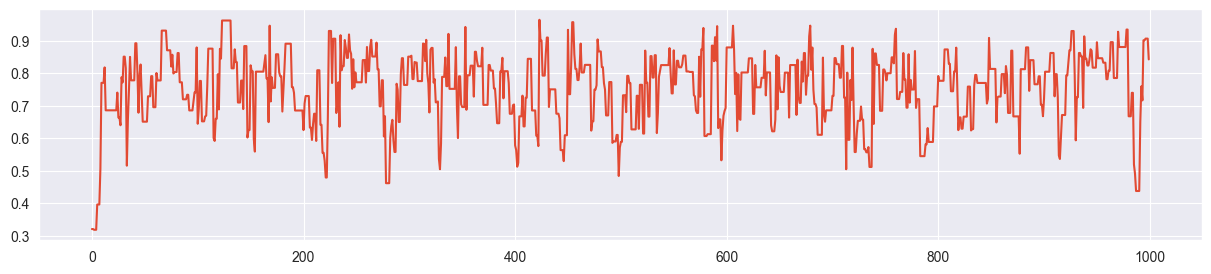

In [7]:
plt.plot( chain )

(looks ok - otherwise tune $\sigma$ as done in the next part)

_Step 1 (hyperparameter tuning): Try out other values of sigma_

  0%|          | 0/1000 [00:00<?, ?it/s]

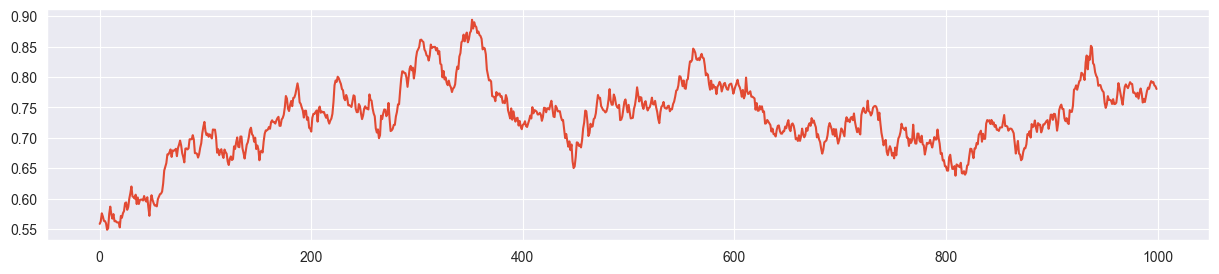

In [8]:
chain = metropolis_chain( 1000, alpha, beta, n, k, sigma=0.01 )
plt.plot( chain )

Example for slow mixing - sigma is too small and the chain explores the parameter space only slowly.

  0%|          | 0/1000 [00:00<?, ?it/s]

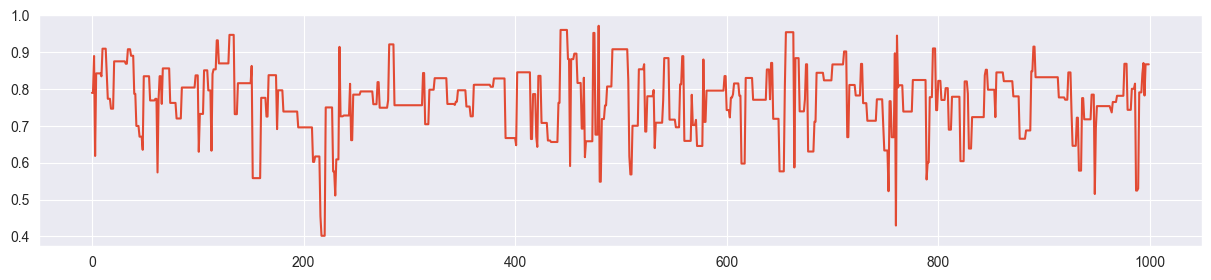

In [9]:
chain = metropolis_chain( 1000, alpha, beta, n, k, sigma=0.5 )
plt.plot( chain )

The chain is often stuck. High rejection rate because sigma is too large and most of the proposals land far away from the mass of the posterior.

`sigma = 0.2` seems more or less ok:

  0%|          | 0/1000 [00:00<?, ?it/s]

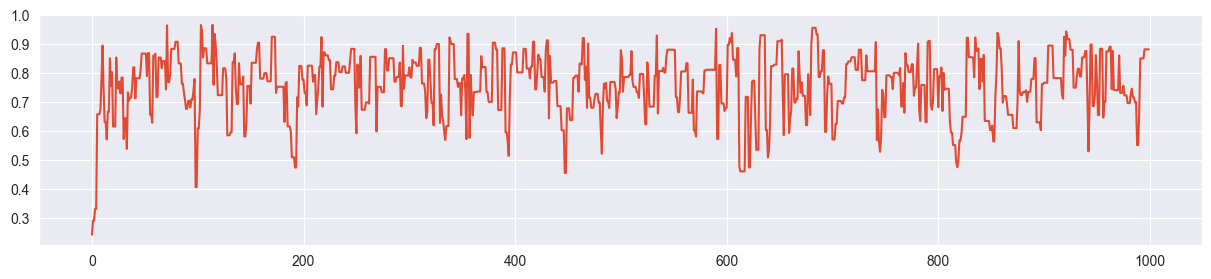

In [10]:
chain = metropolis_chain( 1000, alpha, beta, n, k, sigma=0.2 )
plt.plot( chain )

_Step 2: Visualize distribution_

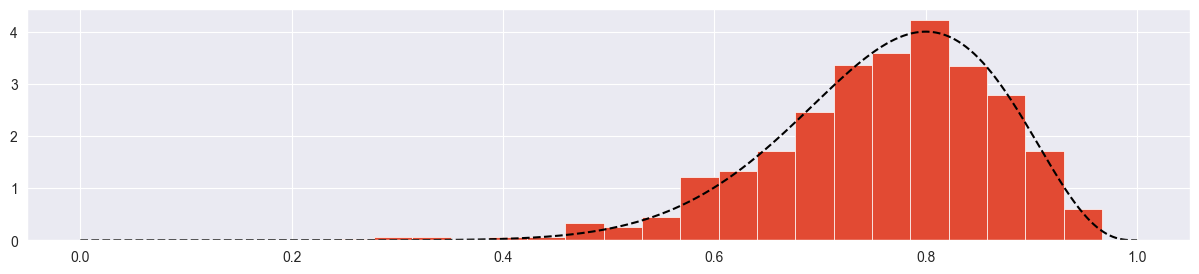

In [11]:
# histogram
plt.hist( chain, density=True, bins=20 )

# true posterior
pi_range = np.linspace(0, 1, 1000)
true_posterior = [stats.beta.pdf(pi, alpha+k, beta+n-k) for pi in pi_range]
plt.plot( pi_range, true_posterior, c="black", ls="--" )

Seems more or less ok! Try with more samples:

  0%|          | 0/4000 [00:00<?, ?it/s]

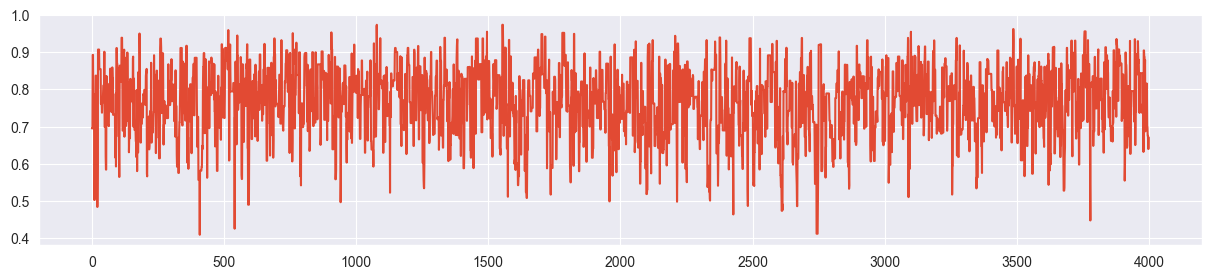

In [12]:
chain = metropolis_chain( 4000, alpha, beta, n, k, sigma=0.2 )
plt.plot( chain )

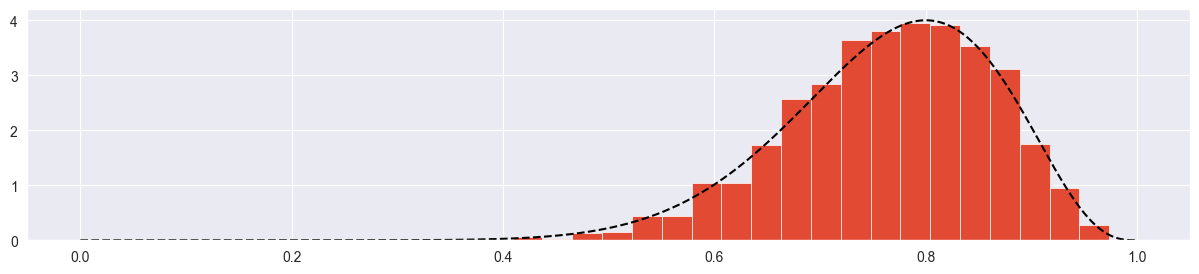

In [13]:
plt.hist( chain, density=True, bins=20 )
plt.plot( pi_range, true_posterior, c="black", ls="--" )

Looks good!

**f) Playing around**

If you have not done this yet: Play around with different values for the proposal jump distribution standard deviation `sigma`. What is the effect on the trace plot and the histogram (see previous part) if you set `sigma` too small, too high or just right? What tells you that you chose `sigma` just right? (apart from the true closed-form posterior distribution).

_`sigma` much too low:_

  0%|          | 0/4000 [00:00<?, ?it/s]

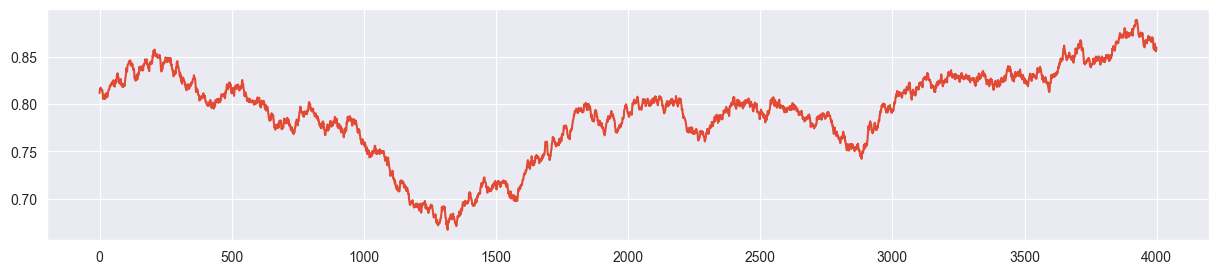

In [14]:
chain = metropolis_chain( 4000, alpha, beta, n, k, sigma=0.002 )
plt.plot( chain )

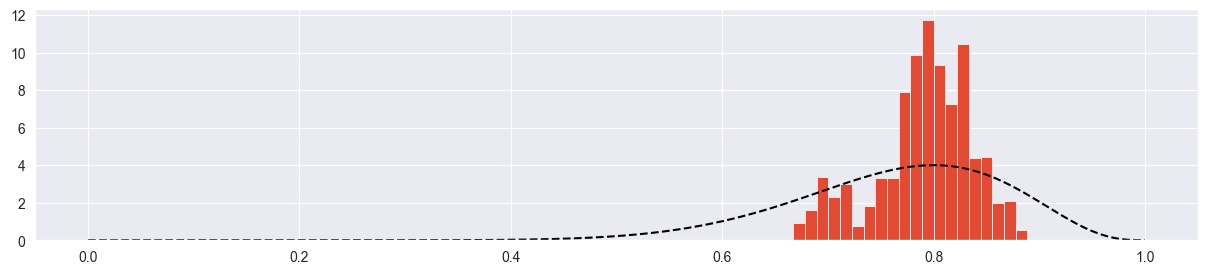

In [15]:
plt.hist( chain, density=True, bins=20 )
plt.plot( pi_range, true_posterior, c="black", ls="--" )

Chain explores only a small part of the parameter space! Acceptance rate is very high because chain always climbs up towards the mode with very small steps. However it barely reaches it.

_`sigma` much too high:_

  0%|          | 0/4000 [00:00<?, ?it/s]

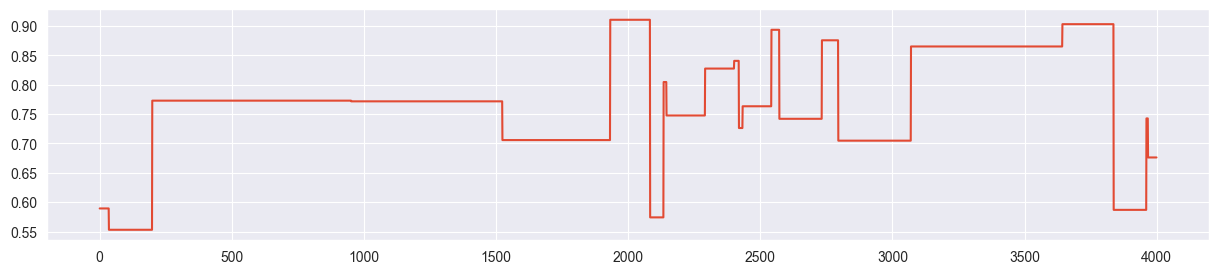

In [16]:
chain = metropolis_chain( 4000, alpha, beta, n, k, sigma=20 )
plt.plot( chain )

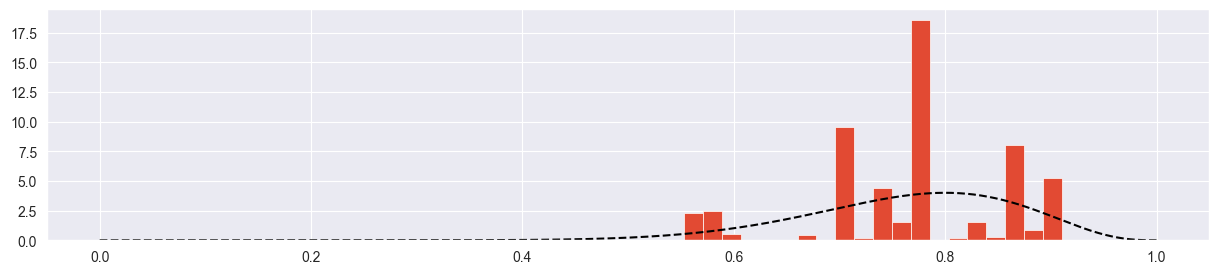

In [17]:
plt.hist( chain, density=True, bins=20 )
plt.plot( pi_range, true_posterior, c="black", ls="--" )

Chain is mostly stuck at the same point and most of the proposals are rejected. Because of this, we only get a few independent samples and the density is concentrated and exaggerated around the points where the chain was stuck.

_`sigma` just right:_

  0%|          | 0/4000 [00:00<?, ?it/s]

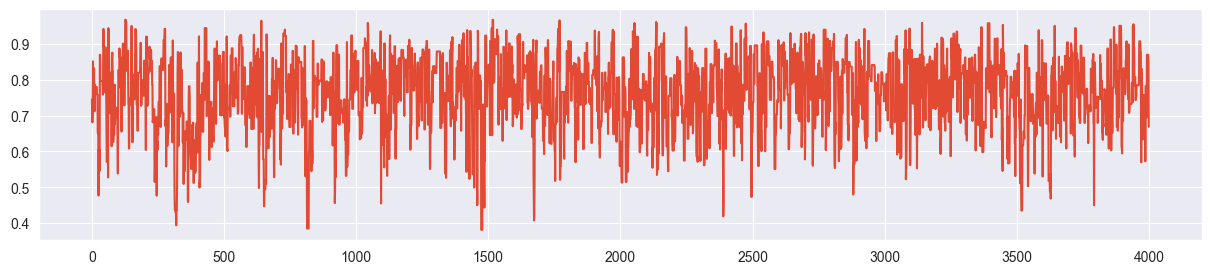

In [18]:
chain = metropolis_chain( 4000, alpha, beta, n, k, sigma=0.2 )
plt.plot( chain )

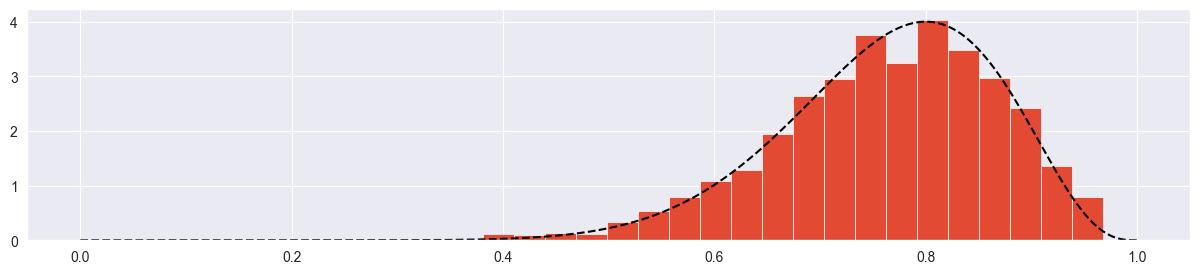

In [19]:
plt.hist( chain, density=True, bins=20 )
plt.plot( pi_range, true_posterior, c="black", ls="--" )

The trace plot looks completely random (not stuck, not creeping), the true distribution is approximated quite nicely.

## Exercise 2: Mult-chain Metropolis algorithm

In the previous exercise you used the trace plot as a diagnostic for whether your chain is healthy (fast mixing). Here we investigate another instrument: density plots of multiple chains.

**a) Multiple chains**

Write a function `metropolis(n_chains, n_steps, alpha, beta, n, k, sigma)` that runs `n_chains` different chains (let's start with 4) using your `metropolis_chain()` function from the previous exercise. Your function should return a numpy array of dimension `(n_steps, n_chains)` that you can then use in the remaining parts of the exercise.

In [20]:
def metropolis( n_chains, n_steps, alpha, beta, n, k, sigma ):
    res = [metropolis_chain( n_steps, alpha, beta, n, k, sigma ) for i in range( n_chains)]
    return np.array(res).T # to have chains in columns

sim = metropolis( 4, 4000, alpha, beta, n, k, sigma=0.2 )
sim.shape

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

(4000, 4)

**b) Trace plots**

Visualize all four trace plots of your chains, use your best value for `sigma` from the previous exercise. Does everything look ok?

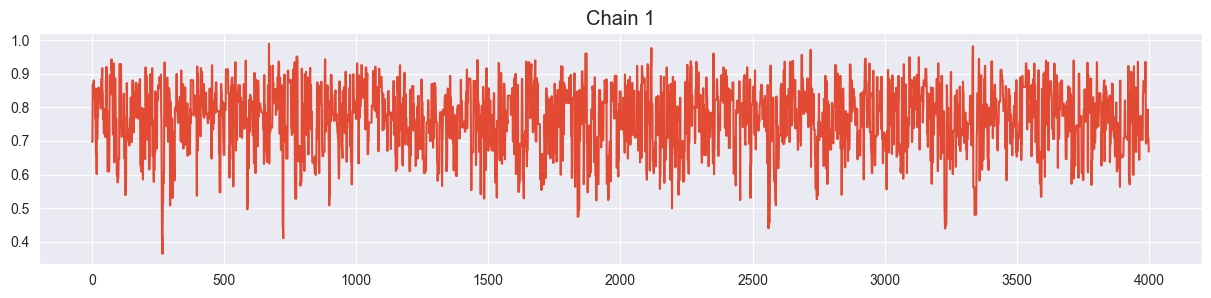

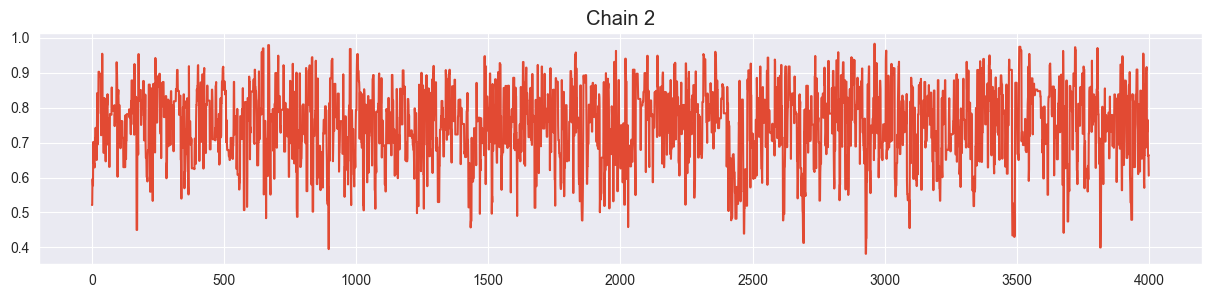

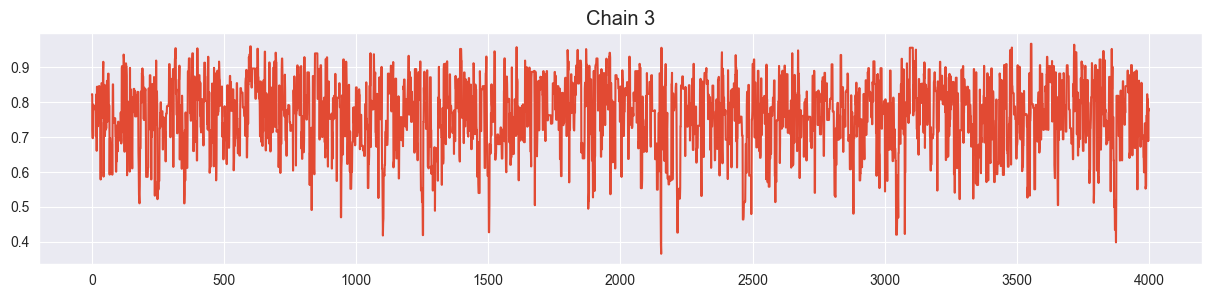

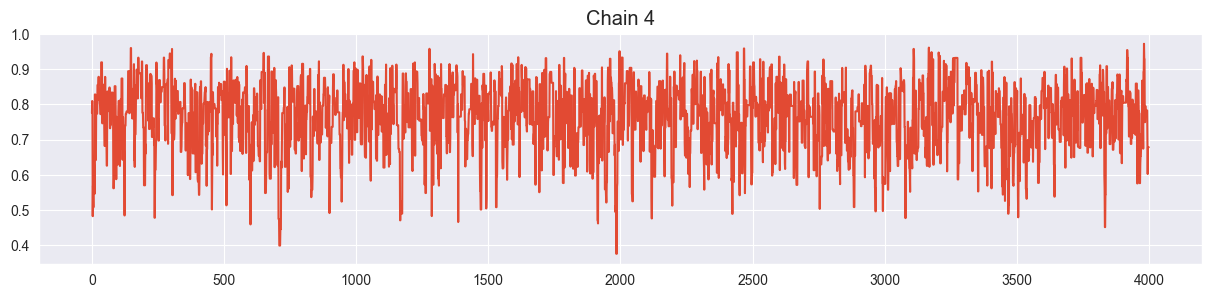

In [21]:
for i in range( sim.shape[1] ):
    plt.figure()
    plt.plot( sim[:,i] )
    plt.title("Chain {}".format(i+1))

Looks ok!

**c) Density plots**

Visualize all four chains in separate density plots (use e.g. `seaborn.kde_plot()`). Are they more or less in agreement? What happens with them if you set `sigma` too large or too small?

_`sigma` just right:_

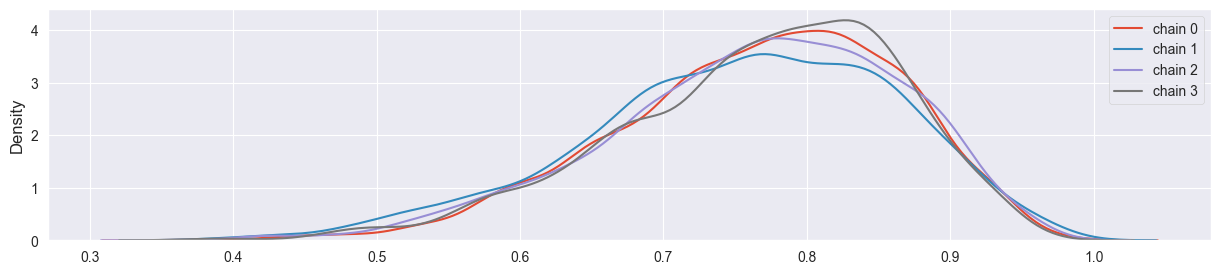

In [22]:
def density_plots( sim ):
    for i in range( sim.shape[1] ):
        sns.kdeplot( sim[:,i], label="chain {}".format(i) )
    plt.legend()

density_plots( sim )

Chains have converged quite well!

_`sigma` too small:_

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

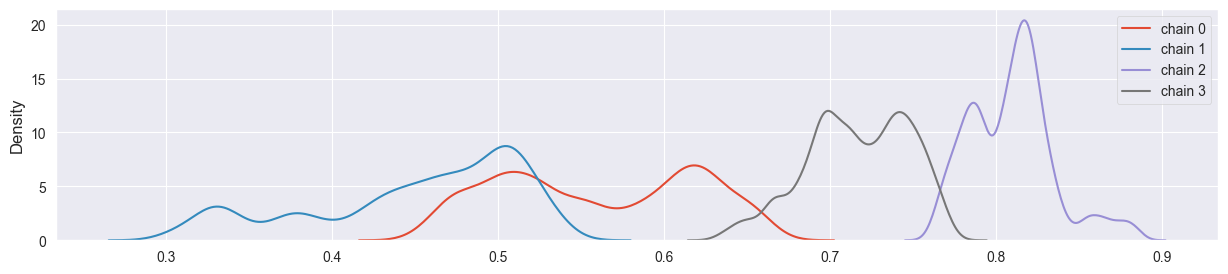

In [23]:
sim = metropolis( 4, 4000, alpha, beta, n, k, sigma=0.002 )
density_plots( sim )

Chains have not converged yet and explore different regions of the parameter space.

_`sigma` too large:_

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

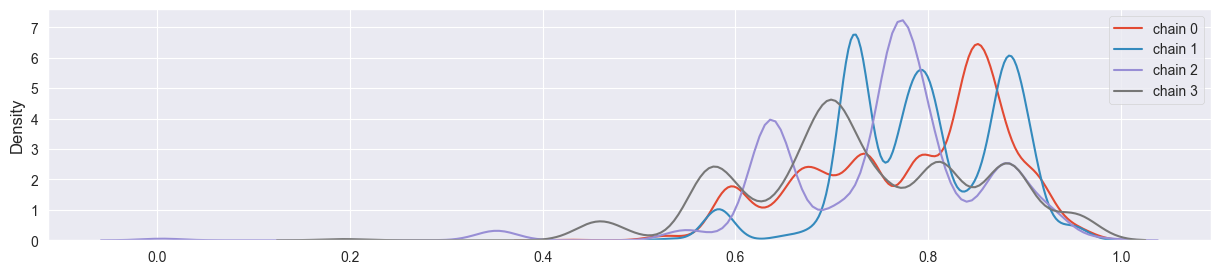

In [24]:
sim = metropolis( 4, 4000, alpha, beta, n, k, sigma=20 )
density_plots( sim )

Chains have not coverged - density plot is misleading, chains are stuck at single points.

**d) $\hat{R}$**

In the lecture we looked at the quantitative measure $\hat{R}$ to indicate how well the four chains converged towards each other. Compute
$$\hat{R}=\sqrt{\frac{Var(x)}{\frac{1}{n_{chains}}\sum_{i}Var(X_{i})}}$$
for your output, where $X_{i}$ is the list of values in chain $i$ and $x$ is the concatenation of all $X_{i}$.
What's the value of $\hat{R}$ for your optimal `sigma`? How does it change if you make `sigma` too small or too high? Is $\hat{R}$ enough to distinguish good from bad chains?

In [25]:
def rhat( sim ):
    total_var = np.var( sim.flatten() )
    individual_var = np.var( sim, axis=0 )
    rhat = np.sqrt( total_var / np.mean(individual_var) )
    return rhat

sim = metropolis( 4, 4000, alpha, beta, n, k, sigma=0.2 )
rhat( sim )

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

1.00017800332027

Very close to 1, this is a sign for a healthy chain!

_`sigma` too small:_

In [26]:
sim = metropolis( 4, 4000, alpha, beta, n, k, sigma=0.002 )
rhat( sim )

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

1.2210161637389108

Rhat is much larger than 1 - this is a sign for a very unhealthy chain!

_`sigma` too large:_

In [27]:
sim = metropolis( 4, 4000, alpha, beta, n, k, sigma=20 )
rhat( sim )

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

1.0087806933180763

Rhat is quite small - however the chains have not converged well! Therefore Rhat alone cannot be used as a single diagnostic, evidence of the unhealthiness can only be found in the trace plot in this case (also an autocorrelation plot and effective sample size could be valuable tools here). 

**e) Burn-in phase**

Is the burn-in phase typically required by the Metropolis algorithm relevant for your beta-binomial problem? Argue using your trace plots.

Let's come back to our healthy chain:

In [28]:
sim = metropolis( 4, 4000, alpha, beta, n, k, sigma=0.2 )

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

Trace plot of first chain (only beginning):

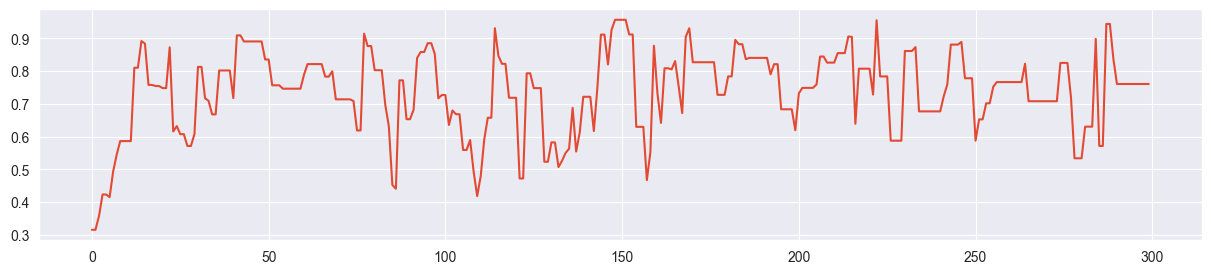

In [29]:
plt.plot( sim[:300,0] )

Since the beta-binomial posterior has a very smooth, one-dimensional probability surface, the Metropolis algorithm finds the mode quickly and appears to require only around 10 samples of burn-in time (depending on the initial value). In the overall size of the chain the burn-in phase can be neglected in this case. This is different for more complicated, multivariate problems!

## Exercise 3: Doing the same with PyMC

**a) MCMC with PyMC**

Reproduce the results from the previous exercise with PyMC (see lecture notes) to demonstrate that PyMC does almost everything for you, except from specifying prior and likelihood of course.

In [30]:
import pymc as pm
with pm.Model() as beta_binom_model:
    pi = pm.Beta( 'pi', alpha=alpha, beta=beta )
    y = pm.Binomial( 'y', p=pi, n=n, observed=k )
    trace = pm.sample(1000)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pi]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


PyMC gives you 4 chains by default and is using the NUTS algorithm in this case.

**b) Investigate the output of `pm.sample()`**

How can you access the samples for $\pi$?

The output of PyMC is an xarray object. Let's have a look at it:

In [31]:
trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [32]:
trace.posterior

<xarray.Dataset> Size: 40kB
Dimensions:  (chain: 4, draw: 1000)
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    pi       (chain, draw) float64 32kB 0.9123 0.8431 0.792 ... 0.6352 0.6352
Attributes:
    created_at:                 2025-12-21T12:43:49.818207
    arviz_version:              0.17.1
    inference_library:          pymc
    inference_library_version:  5.12.0
    sampling_time:              0.3011960983276367
    tuning_steps:               1000

In [33]:
sim = trace.posterior.pi.values
sim.shape

(4, 1000)

This gets us back the values in the chain we produced previously.

**c) Produce diagnostic artefacts and check them**

Produce the following diagnostic artefacts and check whether they look alright (using the PyMC-internal functions or the arviz equivalents):

* trace plot + density plot
* autocorrelation plot
* effective sample size (ESS)
* $\hat{R}$

Finally, if you have graphviz installed, use `pm.model_to_graphviz()` to produce a graphical representation of your very simple model. What is the meaning of the arrow?

_Trace and density plot:_

array([[<Axes: title={'center': 'pi'}>, <Axes: title={'center': 'pi'}>]],
      dtype=object)

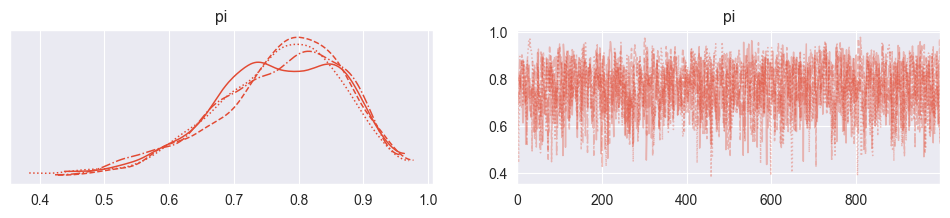

In [34]:
pm.plot_trace( trace )

_Autocorrelation plot (all chains combined):_

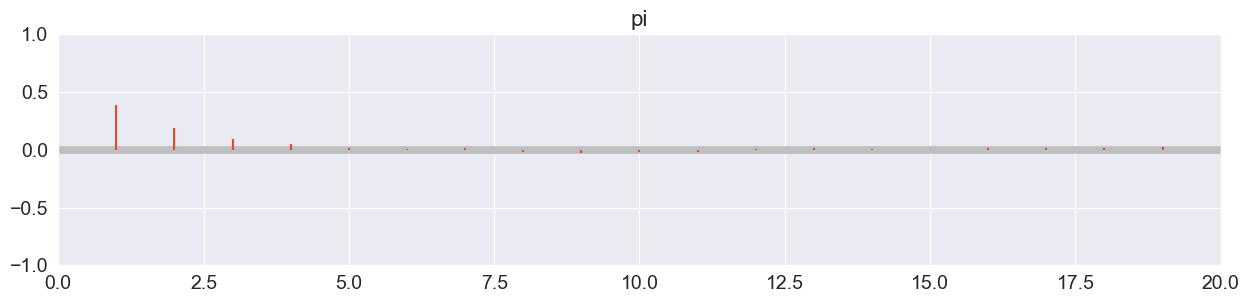

In [35]:
pm.plot_autocorr( trace, combined=True, max_lag=20 );

Drops off extremely quickly!

_Effective sample size (ESS):_

In [36]:
ess = pm.ess( trace ).pi.values
ess

array(1497.64862822)

Considerably lower than 4000! ESS ratio:

In [37]:
ess / 4000

0.3744121570554813

Much larger than the required 10%!

_Rhat:_

In [38]:
pm.rhat( trace ).pi.values

array(1.00282741)

Looks good! (<< 1.05)

Model graph:

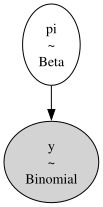

In [39]:
pm.model_to_graphviz( beta_binom_model )

Arrow: the likelihood Bin$(Y=y|\pi)$ depends on $\pi$ (that is modelled by a prior).

**d) Investigate the rank plot**

Some practitioners argue that a rank plot (or trank plot) is better suited to spot bad chains than a trace plot. Investigate what a rank plot is and find out how you can produce it with PyMC. Does it look good for your simulation?

array([[<Axes: title={'center': 'pi'}>,
        <Axes: title={'center': 'pi'}, xlabel='Rank (all chains)', ylabel='Chain'>]],
      dtype=object)

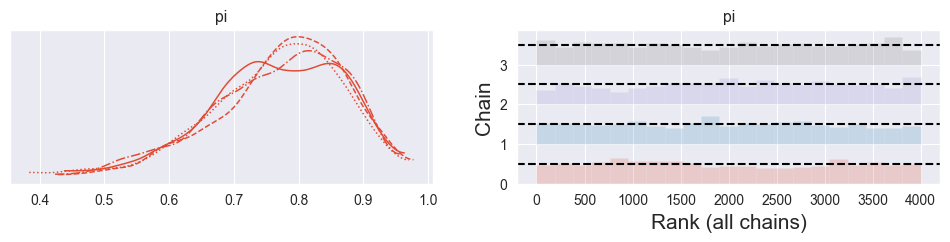

In [40]:
pm.plot_trace( trace, kind="rank_bars" )

The rank (or trank) plot does the following: 
1. Rank the samples from all chains from 1 to 4000 (number samples used here)
2. For each chain individually, produce a histogram of its ranks

For healthy, well-mixing chains, the histograms should be uniform. A spike indicates that the chain got stuck somwhere (producing too many samples of one particular value of $\pi$. Any other asymmetries indicate that the chains did not explore the same regions of the parameter space.

The rank plot above looks good!

More details: Vehtari, Gelman, Simpson, Carpenter, Bürkner. 2019. Rank-normalization, folding, and localization: An improved R-hat for assessing convergence of MCMC. https://arxiv.org/abs/1903.08008

**e) Compare truncated normal prior to beta prior**

A coworker of yours argues that a truncated normal distribution with $\mu=0.8$ and $\sigma=0.2$, truncated between 0 and 1, would describe his prior belief better. Introduce it to your simulation and argue that it does not make a big difference which of these two priors you use. In particular:

1.  do some research to find out what a truncated normal distribution is.
2.  use preliz to visualize your beta prior and your coworker's truncated normal prior and quickly compare them visually.
3.  run a new simulation using your coworker's prior and compare the density plots of both simulations.
4.  use PyMC's `summary()` function to give your coworker a quick comparison. Does it matter a lot which of the two priors you use? What about bulk ESS and tail ESS? (what are they, what does it mean when they are different?)

Plot truncated normal prior:

<Axes: >

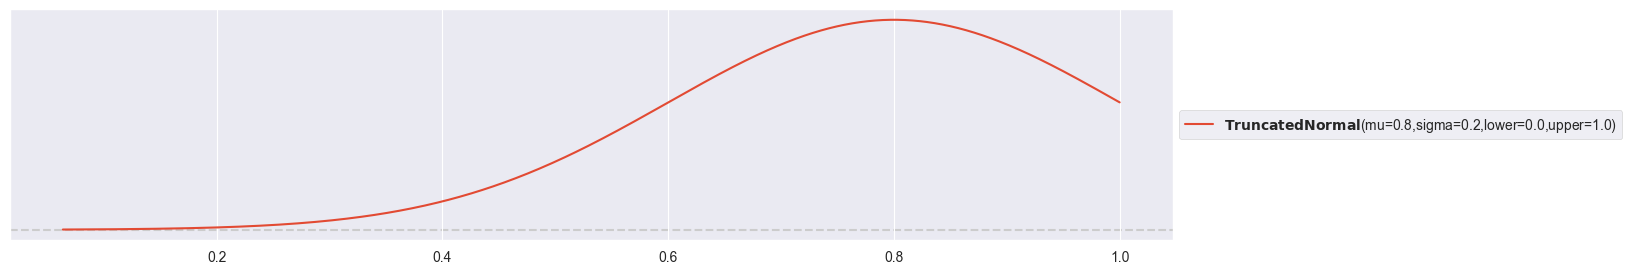

In [41]:
pz.TruncatedNormal( mu=0.8, sigma=0.2, lower=0, upper=1 ).plot_pdf()

Plot previous prior:

<Axes: >

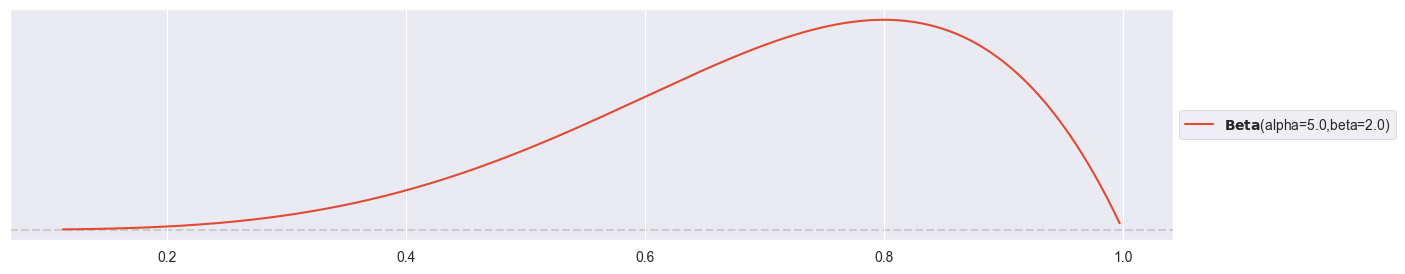

In [42]:
pz.Beta( alpha=alpha, beta=beta ).plot_pdf()

Run simulation with truncated normal prior:

In [43]:
with pm.Model() as normal_binom_model:
    pi = pm.TruncatedNormal( 'pi', mu=0.8, sigma=0.2, lower=0, upper=1 )
    y = pm.Binomial( 'y', p=pi, n=n, observed=k )
    trace2 = pm.sample(1000)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pi]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


Compare densities:

array([[<Axes: title={'center': 'pi'}>, <Axes: title={'center': 'pi'}>]],
      dtype=object)

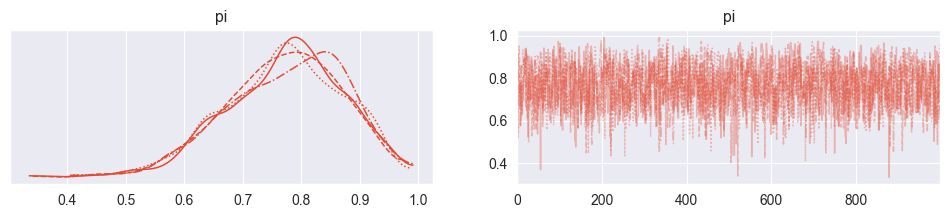

In [44]:
pm.plot_trace( trace2 )

array([[<Axes: title={'center': 'pi'}>, <Axes: title={'center': 'pi'}>]],
      dtype=object)

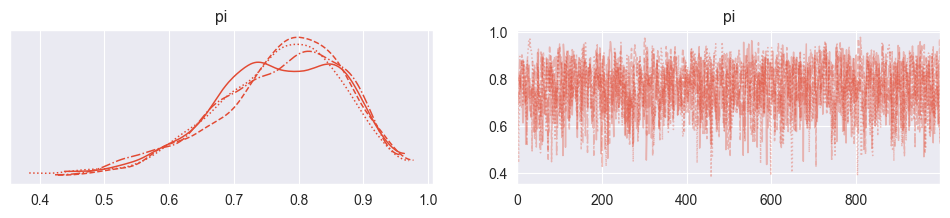

In [45]:
pm.plot_trace( trace )

Compare summaries:

In [46]:
pm.summary( trace2 )

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
pi,0.771,0.1,0.591,0.945,0.002,0.002,1807.0,2060.0,1.0


In [47]:
pm.summary( trace )

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
pi,0.768,0.101,0.581,0.942,0.003,0.002,1498.0,1722.0,1.0


The resulting densities are very similar! It appears that the simulation with the truncated normal prior is numerically a bit less effective, with $\sim400$ less effective samples both in the bulk (center of the distribution) and the tails (periphery). This means that the beta prior produces more accurate estimates at the same computational effort!

## Exercise 4: Foundry

A company produces containers for foundries ('Giessereien') using ceramics and wants to know the maximum temperature such a container can tolerate and in particular also the uncertainty on it. Since finding out this maximum temperature destroys a container, as few measurements as possible should be made.
Your team has started with 10 measurements and wants to know from you (as data scientist) to what accuracy you can make a statement about the average maximum temperature and its uncertainty.

The measurements are (in degrees Celsius):
$$y = [1055, 1053, 1226, 967, 980, 1049, 1040, 1051, 1002, 1057]$$

and you consider the following model:
$$\mu\sim N(\theta,\tau^{2})$$
$$\sigma\sim Exp(1/\lambda)$$
$$y|\mu,\sigma\sim N(\mu,\sigma^{2})$$

You have a prior expectation about $\mu$ (prior normally distributed) and $\sigma$ (prior exponentially distributed) with $\theta=1000^{\circ}$C, $\tau=100^{\circ}$C and $\lambda=100^{\circ}$C and assume a normal likelihood for your data. This is the first time that you see a model where we want to estimate multiple parameters instead of just one. Instead of defining one combined two-dimensional prior for $\mu$ and $\sigma$, we assume independence and define two individual priors. We will discuss this better in the lecture in week 5.

**a) The Exponential Distribution**

Read about the exponential distribution. What is the role of $\lambda$? Does it favour lower or higher values than $\mu$? Visualize $Exp(1/100)$ with preliz. Why would a normal distribution or a beta distribution not be a good prior for $\sigma$?

<Axes: >

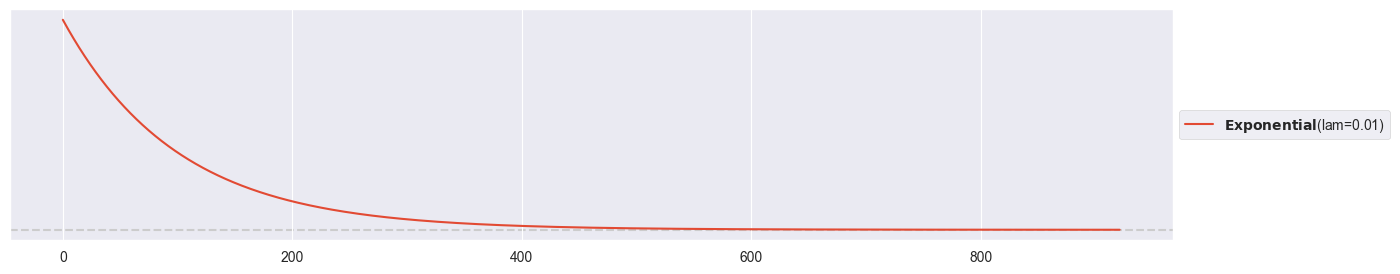

In [48]:
pz.Exponential(1/100).plot_pdf()

In [49]:
pz.Exponential(1/100).mean()

100.0

If $\sigma \sim \text{Exp}(1/\lambda)$, then $E[\sigma] = \lambda$ (see e.g. [Wikipedia](https://en.wikipedia.org/wiki/Exponential_distribution)). Since the exponential distribution is right-skewed, prior values below $100^\circ$ C are favored to values above $100^\circ$ C. 

A normal distribution can't be used as prior for $\sigma$, since it could also produce negative values, and $\sigma$ is strictly positive. A beta distribution is restricted to values between 0 and 1 and $\sigma$ is most likely not. The exponential distribution suits well here, as it produces positive numbers.

**b) Simulate with PyMC**

Carefully formulate the simulation with PyMC and run it. Verify the convergence of your chain using a trank plot and compute posterior summaries with `pm.summary()`. What are your posterior expectations for $\mu$ and $\sigma$ and how do they compare to your prior expectations?

In [50]:
observations = [1055, 1053, 1226,  967,  980, 1049, 1040, 1051, 1002, 1057]

with pm.Model() as normal_normal_model:
    mu = pm.Normal( 'mu', mu=1000, sigma=100 )
    sigma = pm.Exponential( 'sigma', 1/100 )
    y = pm.Normal( 'y', mu=mu, sigma=sigma, observed=observations )
    trace = pm.sample(1000)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


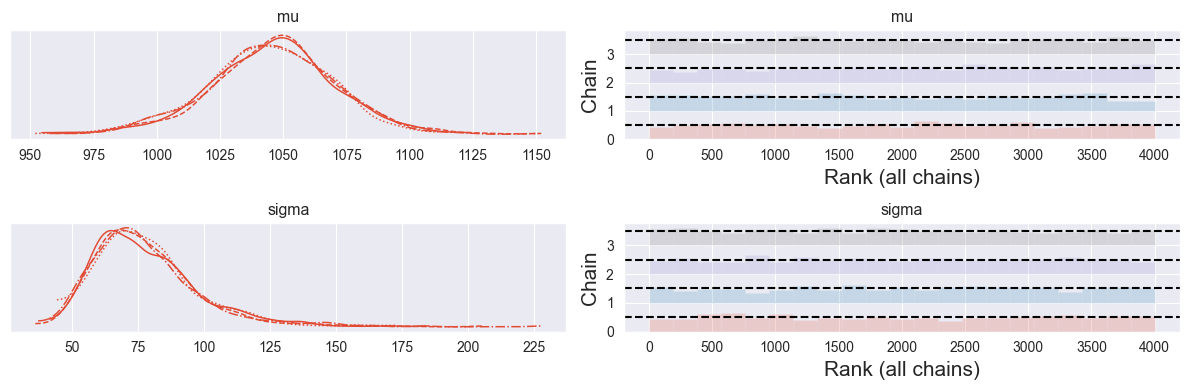

In [51]:
pm.plot_trace( trace, kind="rank_bars" )
plt.tight_layout()

Looks good!

In [52]:
pm.summary( trace )

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,1045.636,24.773,998.782,1094.153,0.476,0.337,2768.0,2333.0,1.0
sigma,77.878,20.136,44.544,113.631,0.412,0.293,2525.0,2532.0,1.0


Your understanding of mean maximum temperature increased from $\mu=1000$ to $\mu=1046$, while your understanding of uncertainty $\sigma$ on this mean maximum temperature decreased from $\sigma=100^\circ$ C to $\sigma=78^\circ$ C.

**c) Visualize your Model**

If you have graphviz installed: Use `pm.model_to_graphviz()` to visualize your model. Can you relate it to the model description above?

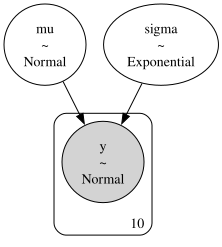

In [53]:
pm.model_to_graphviz( normal_normal_model )

**d) Visualize Parameters**

Extract the first 100 samples for $\mu$ and $\sigma$ from the first chain and visualize them against each other in a two-dimensional plot that shows the evolution of your chain. Can you see evidence for a warm-up phase? Note: Advanced MCMC algorithms do not have a burn-in phase (finding the mass of the posterior), they have a warm-up phase (automatically adjusting the hyperparameters).

Extract Numpy arrays for mu and sigma:

In [54]:
mu_chain = trace.posterior.mu.values
sigma_chain = trace.posterior.sigma.values
mu_chain.shape, sigma_chain.shape

((4, 1000), (4, 1000))

2D plot of parameter space:

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T/ipykernel_69553/4089327092.py:2: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$\mu$")
/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T/ipykernel_69553/4089327092.py:3: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sigma$")


Text(0, 0.5, '$\\sigma$')

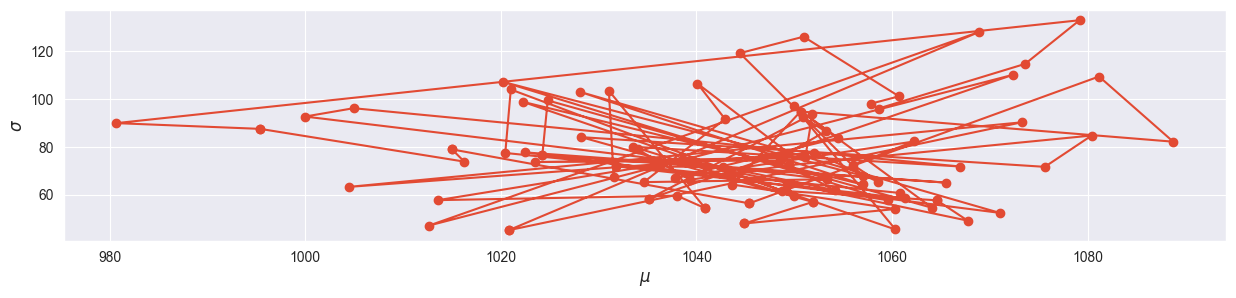

In [55]:
plt.plot( mu_chain[0,:100], sigma_chain[0,:100], marker="o" )
plt.xlabel("$\mu$")
plt.ylabel("$\sigma$")

The warm-up phase can clearly be located away from the mode!